In [ ]:
from dotenv import load_dotenv, find_dotenv
import os

load_dotenv(find_dotenv())
token = os.getenv("KAGGLE_API_TOKEN")

# !kaggle competitions download -c traffic-sign-object-detection-challenge
# !unzip traffic-sign-object-detection-challenge.zip

In [ ]:
from utils.data import convert_coco_to_yolo, generate_yolo_yaml
from utils.inference import run_inference
from utils.viz import visualize_predictions
from utils.train import train_yolo_model
import pandas as pd

In [ ]:
infer_class_map = convert_coco_to_yolo(
    ann_path="dataset/train/annotations.json", 
    img_src_dir="dataset/train/images", 
    yolo_base_dir="dataset/obj"
)
generate_yolo_yaml("data.yaml", "dataset/obj", infer_class_map)

In [ ]:
base_cfg = {
    "data_yaml": "data.yaml",
    "epochs": 32,
    "imgsz": 640,
    "batch": 16,
    "patience": 8,
    "amp": True,
    "device": 0
}

EPOCHS = base_cfg['epochs']
MODEL_VARIANT = "yolo26n"
EXPERIMENT_NAME = f"traffic-sign-{MODEL_VARIANT}-{EPOCHS}"

In [ ]:
train_yolo_model(
    model_variant=f"{MODEL_VARIANT}.pt", 
    experiment_name=EXPERIMENT_NAME,
    **base_cfg
)

In [ ]:
results = run_inference(
    model_path=f"runs/detect/{EXPERIMENT_NAME}/weights/best.pt",
    test_dir="dataset/test/images",
    class_names=infer_class_map
)

In [12]:
df = pd.DataFrame(results)
df.to_csv(f"submission-{EXPERIMENT_NAME}.csv", index=False)

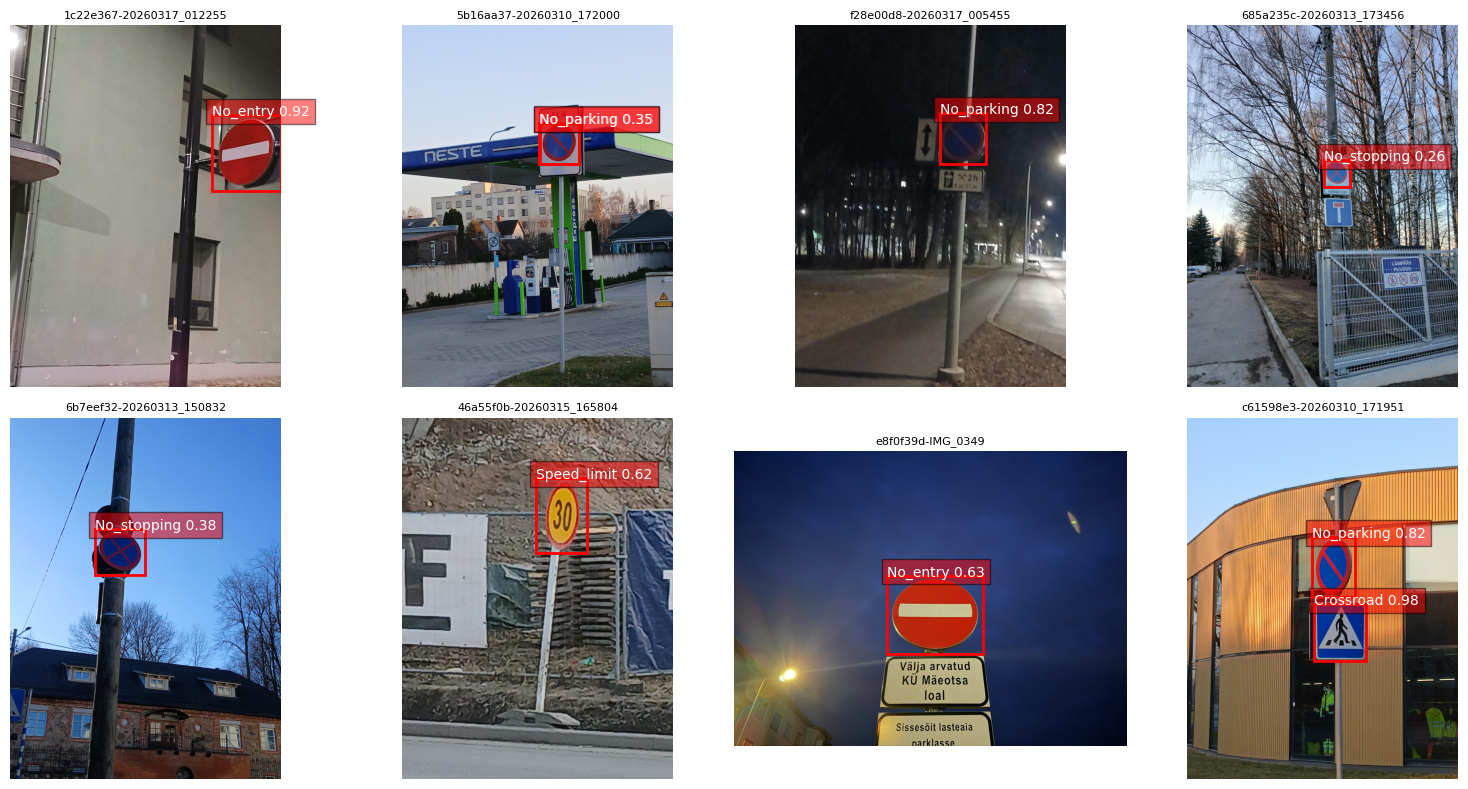

In [11]:
%matplotlib inline
visualize_predictions(results, "dataset/test/images", infer_class_map)